<a href="https://colab.research.google.com/github/JosemCastano17/SyS-2025-ll/blob/main/Copia_de_Detector_Genero_Musical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#0) Reinicio y dependencias



In [ ]:
# Limpieza del entorno de trabajo (opcional pero recomendado al reutilizar el cuaderno)
import shutil, os, sys, subprocess

for d in ["results", "modelo"]:
    shutil.rmtree(d, ignore_errors=True)
os.makedirs("results", exist_ok=True)

# Dependencias
!python3 -m pip install --quiet --force-reinstall https://github.com/yt-dlp/yt-dlp/archive/master.tar.gz
!pip -q install librosa==0.10.1 soundfile scikit-learn umap-learn requests
# ffmpeg suele estar presente; si no, descomenta:
# !apt-get -y -qq install ffmpeg

# Verificar ffmpeg
try:
    out = subprocess.check_output(["ffmpeg", "-version"]).decode().splitlines()[0]
    print("ffmpeg OK:", out)
except Exception as e:
    print("ffmpeg no disponible:", e)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 12.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ffmpeg OK: ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers


#1) Parámetros globales

In [ ]:
import re, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from yt_dlp import YoutubeDL

# Frecuencia de muestreo y segmentación
FS_TARGET = 48000     # Hz
TS        = 5         # segundos por segmento
TL        = np.array([30])  # segundos de inicio por canción (1 punto por canción). Cambia a [30,40,...] si quieres más puntos.

# Columnas esperadas en el Excel
COL_LINK = "link"
COL_BAND = "band"
COL_TYPE = "type"
COL_TNUM = "type_num"

# Mapeo de nombres de género -> índice numérico
GENRE_MAP = {
    "Techno": 1,
    "Psychedelic Rock": 2,
}

print("Parámetros OK.")


Parámetros OK.


#2) Descarga del Excel desde tu Google Sheet

In [ ]:
# Pega aquí tu enlace de Google Sheets (compartido como "cualquiera con el enlace: lector")
SHEETS_LINK = "https://docs.google.com/spreadsheets/d/1fn8uVSu1h7OQae-0pgphqdKOJZMimLLR/edit?usp=sharing&ouid=102376190649773949531&rtpof=true&sd=true"

import re, requests, os

m = re.search(r"/d/([a-zA-Z0-9_-]+)", SHEETS_LINK)
assert m, "No se pudo extraer el ID de la Google Sheet."
SHEET_ID = m.group(1)
EXPORT_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=xlsx"

r = requests.get(EXPORT_URL)
r.raise_for_status()
with open("canciones.xlsx", "wb") as f:
    f.write(r.content)

assert os.path.exists("canciones.xlsx") and os.path.getsize("canciones.xlsx") > 0, "Descarga falló."
print("Descarga OK -> canciones.xlsx")

Descarga OK -> canciones.xlsx


In [ ]:
import pandas as pd, numpy as np, re, unicodedata

file_ = "canciones.xlsx"   # <-- el archivo que ya descargaste

# 1) Leer TODAS las hojas y concatenar
sheets = pd.read_excel(file_, sheet_name=None)
print("Hojas encontradas:", list(sheets.keys()))

frames = []
for sh_name, df in sheets.items():
    if df is None or df.empty:
        continue
    df = df.copy()
    df = df.dropna(how="all")
    df.columns = [str(c).strip() for c in df.columns]
    df["__sheet__"] = sh_name
    frames.append(df)

assert frames, "No se encontraron hojas con contenido."
X = pd.concat(frames, ignore_index=True)
print("Filas totales (todas las hojas):", len(X))

# 2) Normalizar nombres de columnas
COL_LINK = "link"; COL_BAND = "band"; COL_TYPE = "type"; COL_TNUM = "type_num"

def ensure_col(df, target, candidates, default=None):
    cols_map = {str(c).strip().lower(): c for c in df.columns}
    if target in df.columns: return df
    for cand in candidates:
        if cand.lower() in cols_map:
            return df.rename(columns={cols_map[cand.lower()]: target})
    if default is not None and target not in df.columns:
        df[target] = default
    return df

X = ensure_col(X, COL_LINK, ["url","enlace","youtube","youtube_url","video","video_url"])
X = ensure_col(X, COL_BAND, ["banda","artista","artist","autor","grupo"], default="unknown")
X = ensure_col(X, COL_TYPE, ["genre","genero","género","genero_musical","tipo"], default="Techno")
# Si ya viene 'type_num', respétalo (lo coercionamos más abajo)

# Limpiar filas sin link / duplicados de link
X = X[X[COL_LINK].astype(str).str.strip()!=""].copy()
X = X.drop_duplicates(subset=[COL_LINK]).reset_index(drop=True)

# 3) Construir 'type_num' de forma robusta: preferir columna existente; si falta, mapear por texto
def norm_text(s: str) -> str:
    s = str(s)
    s = unicodedata.normalize("NFKD", s)
    s = s.encode("ascii", "ignore").decode("utf-8")
    s = s.replace("-", " ").replace("_", " ").replace("/", " ")
    s = re.sub(r"[^a-zA-Z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip().lower()
    return s

# a) tomar 'type_num' si viene, y normalizar a {1,2} enteros
tn_src = None
if "type_num" in X.columns:
    tn_src = pd.to_numeric(X["type_num"], errors="coerce")
    # Aceptamos 1/2 aunque vengan como float
    tn_src = tn_src.where(tn_src.isin([1,2]))

# b) fallback por texto si type_num está vacío
def map_by_keywords(txt_norm: str):
    if pd.isna(txt_norm): return np.nan
    t = str(txt_norm)
    # Techno si contiene 'techno'
    if "techno" in t:
        return 1
    # Psychedelic Rock por varias formas
    if ("psychedelic" in t) or ("psy rock" in t) or ("psyrock" in t) or re.search(r"\bpsy\b", t):
        return 2
    return np.nan

txt_norm = X[COL_TYPE].astype(str).map(norm_text)
tn_kw = txt_norm.map(map_by_keywords)

# c) coalesce: primero lo que venía en type_num, si no, el del texto
X[COL_TNUM] = tn_src.fillna(tn_kw) if tn_src is not None else tn_kw

# d) filtrar solo 1/2 y reportar las no mapeadas
no_mapped = X[X[COL_TNUM].isna()]
if len(no_mapped):
    print("ATENCIÓN: filas sin género mapeado a {1=Techno, 2=Psychedelic Rock}. Revísalas:")
    display(no_mapped[[COL_LINK, COL_BAND, COL_TYPE, "__sheet__"]].head(20))

X = X[X[COL_TNUM].isin([1,2])].reset_index(drop=True)

# e) Reporte final
dist = (X
        .assign(_g=X[COL_TNUM].map({1:"Techno",2:"Psychedelic Rock"}))
        .groupby("_g")[COL_TNUM].agg(['count','min','max']))
print("Distribución por género (tras coalesce y filtro):")
display(dist)
print("Total de filas válidas:", len(X))
assert len(X)>0, "No hay filas válidas tras el mapeo."


Hojas encontradas: ['Hoja 1']
Filas totales (todas las hojas): 30
Distribución por género (tras coalesce y filtro):


,count,min,max
_g,,,
Psychedelic Rock,15,2,2
Techno,15,1,1


Total de filas válidas: 30


#3) Normalización de columnas y mapeo de géneros 1/2




In [ ]:
# === Sección 3: NORMALIZAR COLUMNAS y MAPEAR GÉNEROS (sin defaults peligrosos) ===
import pandas as pd, numpy as np, re, unicodedata

COL_LINK = "link"; COL_BAND = "band"; COL_TYPE = "type"; COL_TNUM = "type_num"

def ensure_col(df, target, candidates):
    cols_map = {str(c).strip().lower(): c for c in df.columns}
    if target in df.columns:
        return df
    for cand in candidates:
        if cand.lower() in cols_map:
            return df.rename(columns={cols_map[cand.lower()]: target})
    raise AssertionError(f"No se encontró la columna requerida '{target}'. "
                         f"Intenta renombrar tu hoja (p. ej. '{candidates[0]}'). "
                         f"Columnas actuales: {list(df.columns)}")

# 1) Asegurar columnas estándar (SIN defaults)
X.columns = [str(c).strip() for c in X.columns]
X = ensure_col(X, COL_LINK, ["url","enlace","youtube","youtube_url","video","video_url"])
X = ensure_col(X, COL_BAND, ["banda","artista","artist","autor","grupo"])
X = ensure_col(X, COL_TYPE, ["genre","genero","género","genero_musical","tipo"])

# 2) Limpiar filas sin link
X = X[X[COL_LINK].astype(str).str.strip() != ""].copy()

# 3) Deduplicado (si quieres). ¡OJO!: si deduplicas SOLO por 'link',
#    te puedes comer filas del otro género si por error comparten el link.
#    Mejor deduplicar por (link, type), o directamente no deduplicar.
X = X.drop_duplicates(subset=[COL_LINK, COL_TYPE]).reset_index(drop=True)
# Si prefieres NO deduplicar:
# X = X.reset_index(drop=True)

# 4) Normalizador agresivo para texto de género
def norm_text(s: str) -> str:
    s = str(s)
    s = unicodedata.normalize("NFKD", s)
    s = s.encode("ascii", "ignore").decode("utf-8")   # fuera acentos/NBSP/ZWJ
    s = s.replace("-", " ").replace("_", " ").replace("/", " ")
    s = re.sub(r"[^a-zA-Z0-9\s]", " ", s)            # deja solo letras/números/espacios
    s = re.sub(r"\s+", " ", s).strip().lower()
    return s

X["__type_norm__"] = X[COL_TYPE].astype(str).map(norm_text)

print("Formas normalizadas de 'type' detectadas (primeras 20):")
display(pd.DataFrame(sorted(X["__type_norm__"].unique())).head(20))

# 5) Preferir 'type_num' si ya viene (1/2). Si no, mapear por palabras clave (EN/ES).
tn_src = None
if COL_TNUM in X.columns:
    tn_src = pd.to_numeric(X[COL_TNUM], errors="coerce")
    tn_src = tn_src.where(tn_src.isin([1,2]))

def map_by_keywords(t: str):
    if pd.isna(t):
        return np.nan
    # Techno (cualquier variante que contenga 'techno')
    if re.search(r"\btechno\b", t):
        return 1
    # Psychedelic Rock (varias formas EN/ES)
    if ("psychedelic" in t) or re.search(r"\bpsy\b", t) or ("psy rock" in t) or ("psyrock" in t):
        return 2
    if ("psicodelic" in t) or ("psicodelico" in t) or ("psicodelica" in t) or ("psicodelia" in t):
        return 2
    return np.nan

tn_kw = X["__type_norm__"].map(map_by_keywords)
X[COL_TNUM] = tn_src.fillna(tn_kw) if tn_src is not None else tn_kw

# 6) Mostrar filas que no mapean (para corregir en la Sheet si hiciera falta)
no_mapped = X[X[COL_TNUM].isna()]
if len(no_mapped):
    print("ATENCIÓN: filas sin género mapeado a {1=Techno, 2=Psychedelic Rock}. Revísalas o ajusta las reglas:")
    display(no_mapped[[COL_LINK, COL_BAND, COL_TYPE, "__type_norm__"]].head(30))

# 7) Filtrar solo {1,2} y reporte
X = X[X[COL_TNUM].isin([1,2])].reset_index(drop=True)

dist = (X.assign(_g=X[COL_TNUM].map({1:"Techno", 2:"Psychedelic Rock"}))
          .groupby("_g")[COL_TNUM].agg(['count','min','max']))
print("Distribución por género (final):")
display(dist)
print("Total de filas válidas:", len(X))
assert len(X) > 0, "No hay filas válidas tras el mapeo."


Formas normalizadas de 'type' detectadas (primeras 20):


,0
0,psychedelic rock
1,techno


Distribución por género (final):


,count,min,max
_g,,,
Psychedelic Rock,15,2,2
Techno,15,1,1


Total de filas válidas: 30


#4) (Opcional) Cargar cookies de YouTube para evitar bloqueos


In [ ]:
# Si algunos enlaces piden "Sign in to confirm you’re not a bot", sube un cookies.txt (formato Netscape)
# Obtenido con una extensión tipo "Get cookies.txt" estando logueado en YouTube.
# Si no quieres usar cookies, ejecuta la celda y cancela el cuadro de selección.

from google.colab import files

COOKIES_FILE = None
try:
    uploaded = files.upload()  # selecciona cookies.txt si lo tienes
    if uploaded:
        COOKIES_FILE = next(iter(uploaded))
        print("Cookies cargadas:", COOKIES_FILE)
except Exception as e:
    print("No se subieron cookies:", e)


Saving www.youtube.com_cookies.txt to www.youtube.com_cookies (3).txt
Cookies cargadas: www.youtube.com_cookies (3).txt


#5) Utilidades: nombres seguros, descarga con yt-dlp y conversión a WAV

In [ ]:
import os, subprocess

def safe_name(s: str) -> str:
    return re.sub(r'[^a-zA-Z0-9_\-\.]+', '_', s.strip())

def ytdlp_download(url: str, out_basename: str, cookies_path: str = None) -> str:
    """
    Descarga mejor audio. Si YouTube pide login/antibot y hay cookies, reintenta con cookies.
    Devuelve la ruta del archivo descargado con su extensión real (.m4a/.webm/.opus/.mp3).
    """
    def _run(cookies=None):
        ydl_opts = {
            'format'   : 'bestaudio/best',
            'keepvideo': False,
            'outtmpl'  : out_basename + ".%(ext)s",
            'quiet'    : False,
            'extractor_args': {'youtube': {'player_client': ['default']}},
            'http_headers': {'User-Agent': 'Mozilla/5.0'},
        }
        if cookies:
            ydl_opts['cookiefile'] = cookies
        with YoutubeDL(ydl_opts) as ydl:
            info = ydl.extract_info(url, download=True)  # puede lanzar excepción
        return info

    # Primero sin cookies
    try:
        info = _run(cookies=None)
    except Exception as e:
        msg = str(e)
        needs_login = ("Sign in to confirm you're not a bot" in msg) or ("Sign in to confirm you’re not a bot" in msg)
        if needs_login and cookies_path and os.path.exists(cookies_path):
            print("Reintentando con cookies...")
            info = _run(cookies=cookies_path)
        else:
            raise

    title = info.get('title', '(sin título)')
    print("Descarga completa:", title)

    # Localizar archivo descargado sin asumir extensión
    matches = glob.glob(out_basename + ".*")
    if not matches:
        raise RuntimeError("No se encontró el archivo descargado para " + out_basename)
    for cand in matches:
        if not cand.lower().endswith(".wav"):
            return cand
    return matches[0]

def convert_to_wav48(src_path: str, dst_path: str):
    cmd = ['ffmpeg', '-y', '-i', src_path, '-ac', '2', '-ar', str(FS_TARGET), dst_path]
    try:
        subprocess.run(cmd, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    except subprocess.CalledProcessError as e:
        err = e.stderr.decode(errors='ignore')[:1500]
        print("Error ffmpeg:\n", err)
        raise


#6) Descarga y conversión de todas las canciones del Excel



In [ ]:
# Recomendado: carpeta limpia ya creada en sección 0. Si quieres, vuelve a limpiar:
# import shutil; shutil.rmtree("results", ignore_errors=True); os.makedirs("results", exist_ok=True)

N = len(X)
print(f"Total filas en X: {N}")
cookies_path = COOKIES_FILE if COOKIES_FILE and os.path.exists(COOKIES_FILE) else None
print("Usando cookies:", cookies_path)

errores = []

for n in range(N):
    link = str(X.loc[n, COL_LINK]).strip()
    band = safe_name(str(X.loc[n, COL_BAND]))
    tnum = int(X.loc[n, COL_TNUM])

    print(f"\nvideo {n+1} de {N}")
    print("link:", link)
    print("band:", band)
    print("type:", X.loc[n, COL_TYPE])

    basename = f"results/{band}_{n}_{tnum}"
    wav_out  = basename + ".wav"
    if os.path.exists(wav_out) and os.path.getsize(wav_out) > 0:
        print("Ya existe WAV, se omite:", wav_out)
        continue

    try:
        src = ytdlp_download(link, basename, cookies_path=cookies_path)
        convert_to_wav48(src, wav_out)
        print("OK ->", wav_out)
    except Exception as e:
        print("Saltando por error:", e)
        errores.append({'n': n, 'link': link, 'band': band, 'type': X.loc[n, COL_TYPE], 'error': str(e)})

print("\nResumen:")
print("Convertidos OK:", N - len(errores))
print("Saltados:", len(errores))
if errores:
    display(pd.DataFrame(errores))


Total filas en X: 30
Usando cookies: www.youtube.com_cookies (3).txt

video 1 de 30
link: https://www.youtube.com/watch?v=1BNYhpyNPiI
band: Pan-Pot
type: Techno
[youtube] Extracting URL: https://www.youtube.com/watch?v=1BNYhpyNPiI
[youtube] 1BNYhpyNPiI: Downloading webpage
[youtube] 1BNYhpyNPiI: Downloading android sdkless player API JSON
[youtube] 1BNYhpyNPiI: Downloading web safari player API JSON


[youtube] 1BNYhpyNPiI: Downloading m3u8 information


[info] 1BNYhpyNPiI: Downloading 1 format(s): 251
[download] Sleeping 5.00 seconds as required by the site...
[download] Destination: results/Pan-Pot_0_1.webm
[download] 100% of    6.17MiB in 00:00:00 at 24.17MiB/s  
Descarga completa: Pan-Pot - Nightcode (Extended Mix) [Second State | HUMAN]
OK -> results/Pan-Pot_0_1.wav

video 2 de 30
link: https://youtu.be/y51tm2-IRUc?si=t6GwZnA3JY5tomWR
band: Funk_Tribu
type: Techno
[youtube] Extracting URL: https://youtu.be/y51tm2-IRUc?si=t6GwZnA3JY5tomWR
[youtube] y51tm2-IRUc: Downloading webpage
[youtube] y51tm2-IRUc: Downloading android sdkless player API JSON
[youtube] y51tm2-IRUc: Downloading web safari player API JSON


[youtube] y51tm2-IRUc: Downloading m3u8 information


[info] y51tm2-IRUc: Downloading 1 format(s): 251
[download] Sleeping 5.00 seconds as required by the site...
[download] Destination: results/Funk_Tribu_1_1.webm
[download] 100% of    4.03MiB in 00:00:00 at 26.77MiB/s  
Descarga completa: Funk Tribu - Hold On (Official Visualizer)
OK -> results/Funk_Tribu_1_1.wav

video 3 de 30
link: https://www.youtube.com/watch?v=FZjPMsly2Mk
band: indira_paganotto
type: Techno
[youtube] Extracting URL: https://www.youtube.com/watch?v=FZjPMsly2Mk
[youtube] FZjPMsly2Mk: Downloading webpage
[youtube] FZjPMsly2Mk: Downloading android sdkless player API JSON
[youtube] FZjPMsly2Mk: Downloading web safari player API JSON


...

[info] j81Vx-0uM0k: Downloading 1 format(s): 251
[download] Sleeping 5.00 seconds as required by the site...
[download] Destination: results/JJ_Cale_27_2.webm
[download] 100% of    2.20MiB in 00:00:00 at 13.86MiB/s  
Descarga completa: After Midnight - JJ Cale
OK -> results/JJ_Cale_27_2.wav

video 29 de 30
link: https://youtu.be/O8WzDO_hj8A?si=b2Ht0Q3ZRk77ZQz3
band: JJ_Cale
type: psychedelic rock
[youtube] Extracting URL: https://youtu.be/O8WzDO_hj8A?si=b2Ht0Q3ZRk77ZQz3
[youtube] O8WzDO_hj8A: Downloading webpage
[youtube] O8WzDO_hj8A: Downloading android sdkless player API JSON
[youtube] O8WzDO_hj8A: Downloading web safari player API JSON


[youtube] O8WzDO_hj8A: Downloading m3u8 information


[info] O8WzDO_hj8A: Downloading 1 format(s): 251
[download] Sleeping 5.00 seconds as required by the site...
[download] Destination: results/JJ_Cale_28_2.webm
[download] 100% of    3.53MiB in 00:00:00 at 21.01MiB/s  
Descarga completa: JJ Cale - Magnolia
OK -> results/JJ_Cale_28_2.wav

video 30 de 30
link: https://youtu.be/mAi8-BS_6dE?si=FbjRA_eEB4B0bUrI
band: JJ_Cale
type: psychedelic rock
[youtube] Extracting URL: https://youtu.be/mAi8-BS_6dE?si=FbjRA_eEB4B0bUrI
[youtube] mAi8-BS_6dE: Downloading webpage
[youtube] mAi8-BS_6dE: Downloading android sdkless player API JSON
[youtube] mAi8-BS_6dE: Downloading web safari player API JSON


[youtube] mAi8-BS_6dE: Downloading m3u8 information


[info] mAi8-BS_6dE: Downloading 1 format(s): 251
[download] Sleeping 6.00 seconds as required by the site...
[download] Destination: results/JJ_Cale_29_2.webm
[download] 100% of    4.87MiB in 00:00:00 at 26.41MiB/s  
Descarga completa: Sensitive Kind - JJ Cale
OK -> results/JJ_Cale_29_2.wav

Resumen:
Convertidos OK: 30
Saltados: 0


#7) Segmentación en 5 s y etiquetas coherentes con el Excel

In [ ]:
import soundfile as sf
from scipy.signal import resample_poly
from math import gcd

path = "results/"
wav_files = sorted([f for f in os.listdir(path) if f.endswith(".wav")])
print("WAVs encontrados:", len(wav_files))

seg_len = int(TS * FS_TARGET)
Ns = len(wav_files) * len(TL)

x_t   = np.zeros((Ns, seg_len, 2), dtype=np.float32)
label = np.zeros((Ns,1), dtype=np.int32)
name_c = []

i = 0
for name in wav_files:
    # Parseo robusto: <band>_<idx>_<type_num>.wav
    stem = name[:-4]
    parts = stem.rsplit("_", 2)
    if len(parts) != 3:
        print("Nombre inesperado:", name, " -> omitido")
        continue
    band_part, idx_str, tnum_str = parts
    try:
        idx_in_X = int(idx_str)
        tnum_from_name = int(tnum_str)
    except:
        print("No se pudo parsear idx/type_num en:", name, " -> omitido")
        continue

    if not (0 <= idx_in_X < len(X)):
        print("idx fuera de rango para X en", name, " -> omitido")
        continue

    tnum_from_X = int(X.loc[idx_in_X, COL_TNUM])
    if tnum_from_X != tnum_from_name:
        print(f"Advertencia: type_num en nombre ({tnum_from_name}) != X ({tnum_from_X}). Usando X.")
    tnum_final = tnum_from_X

    x, fs_i = sf.read(os.path.join(path, name))
    if x.ndim == 1:
        x = np.expand_dims(x, 1)
    if x.shape[1] == 1:
        x = np.repeat(x, 2, axis=1)

    # Re-muestreo si hiciera falta (debería ser 48 kHz ya)
    if fs_i != FS_TARGET:
        g = gcd(FS_TARGET, fs_i)
        up = FS_TARGET // g
        down = fs_i // g
        ch1 = resample_poly(x[:,0], up=up, down=down)
        ch2 = resample_poly(x[:,1], up=up, down=down)
        x = np.stack((ch1, ch2), axis=-1)

    # Validar duración
    if x.shape[0] < int((TL[-1] + TS) * FS_TARGET):
        valid_tl = TL[TL + TS <= x.shape[0]/FS_TARGET]
    else:
        valid_tl = TL

    for t0 in valid_tl:
        i0 = int(t0 * FS_TARGET)
        i1 = i0 + seg_len
        if i1 > x.shape[0]:
            continue
        xc = x[i0:i1, :]

        # Asegurar longitud exacta
        if xc.shape[0] > seg_len:
            xc = xc[:seg_len, :]
        elif xc.shape[0] < seg_len:
            pad = np.zeros((seg_len - xc.shape[0], 2), dtype=xc.dtype)
            xc = np.vstack((xc, pad))

        x_t[i]   = xc
        label[i] = tnum_final
        name_c.append(f"{band_part}_{idx_in_X}")
        i += 1

# Truncar a los segmentos válidos
x_t   = x_t[:i]
label = label[:i]
name_c = name_c[:i]
print("Forma de x_t:", x_t.shape, " - segmentos válidos:", i)
print("Clases encontradas:", np.unique(label).ravel().tolist())


WAVs encontrados: 30
Forma de x_t: (30, 240000, 2)  - segmentos válidos: 30
Clases encontradas: [1, 2]


#8) FFT, normalización y UMAP 2D

In [ ]:
# Importaciones y configuración
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from umap import UMAP

# Detectar frecuencia de muestreo
_fs = globals().get('FS_TARGET', globals().get('fs', 48000))


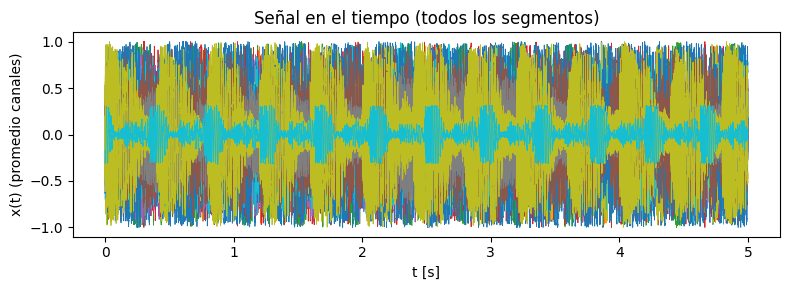

In [ ]:
# -------- 8.1 Señal en el tiempo (promedio de canales) --------
t = np.arange(x_t.shape[1]) / _fs
plt.figure(figsize=(8,3))
plt.plot(t, x_t.mean(axis=-1).T, linewidth=0.6)
plt.xlabel('t [s]')
plt.ylabel('x(t) (promedio canales)')
plt.title('Señal en el tiempo (todos los segmentos)')
plt.tight_layout()
plt.show()

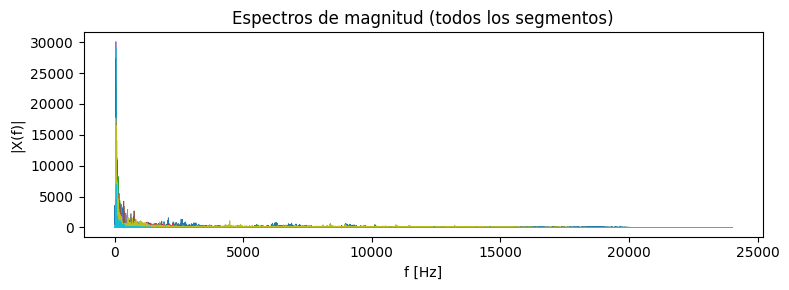

In [ ]:
# -------- 8.2 FFT y espectros de magnitud |X(f)| --------
vf = np.fft.rfftfreq(x_t.shape[1], 1/_fs)
Xw  = np.fft.rfft(x_t, axis=1).mean(axis=-1)   # promedio de canales
Xw_abs = np.abs(Xw)

plt.figure(figsize=(8,3))
plt.plot(vf, Xw_abs.T, linewidth=0.6)
plt.xlabel('f [Hz]')
plt.ylabel('|X(f)|')
plt.title('Espectros de magnitud (todos los segmentos)')
plt.tight_layout()
plt.show()

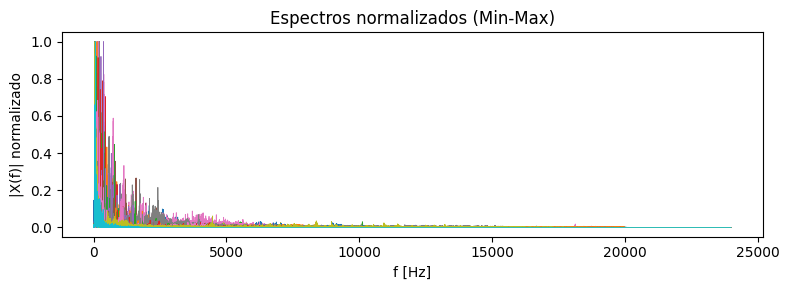

In [ ]:
# -------- 8.3 Normalización Min-Max por columna (como en el cuaderno) --------
sca = MinMaxScaler()
Xw_ = sca.fit_transform(Xw_abs.T).T  # normalizar columnas (segmentos)

plt.figure(figsize=(8,3))
plt.plot(vf, Xw_.T, linewidth=0.6)
plt.xlabel('f [Hz]')
plt.ylabel('|X(f)| normalizado')
plt.title('Espectros normalizados (Min-Max)')
plt.tight_layout()
plt.show()

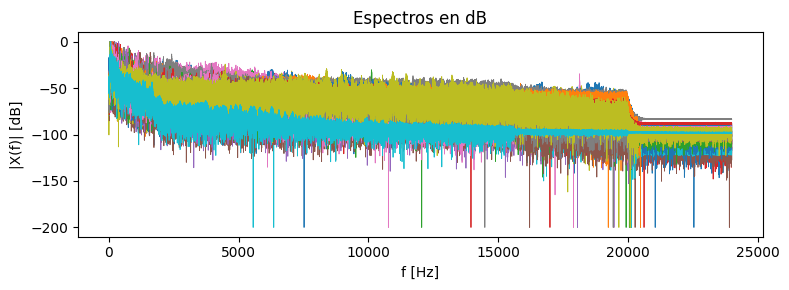

In [ ]:
# -------- 8.4 Espectros en dB --------
plt.figure(figsize=(8,3))
plt.plot(vf, (20*np.log10(Xw_ + 1e-10)).T, linewidth=0.6)  # 1e-10 para evitar log(0)
plt.xlabel('f [Hz]')
plt.ylabel('|X(f)| [dB]')
plt.title('Espectros en dB')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


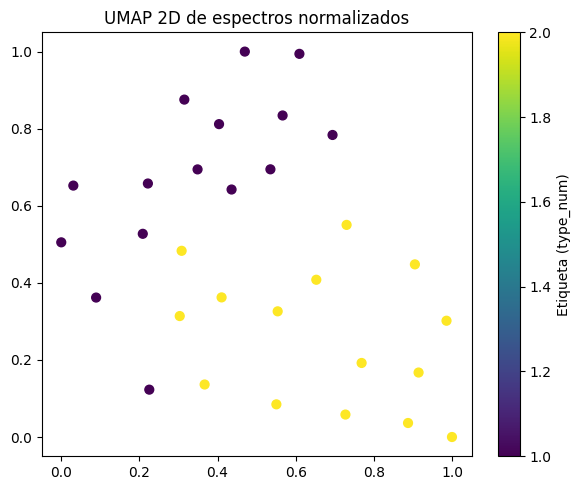

In [ ]:
# -------- 8.5 UMAP 2D (más separación visual) --------
umap = UMAP(n_components=2, n_neighbors=5, min_dist=0.5, metric='euclidean', random_state=42)
X_2D = umap.fit_transform(Xw_)                  # reducir
X_2D = MinMaxScaler().fit_transform(X_2D)       # reescalar a [0,1] solo para dibujar

plt.figure(figsize=(6,5))
plt.scatter(X_2D[:,0], X_2D[:,1], c=label.ravel(), s=40, cmap='viridis')
plt.colorbar(label='Etiqueta (type_num)')
plt.title('UMAP 2D de espectros normalizados')
plt.tight_layout()
plt.show()

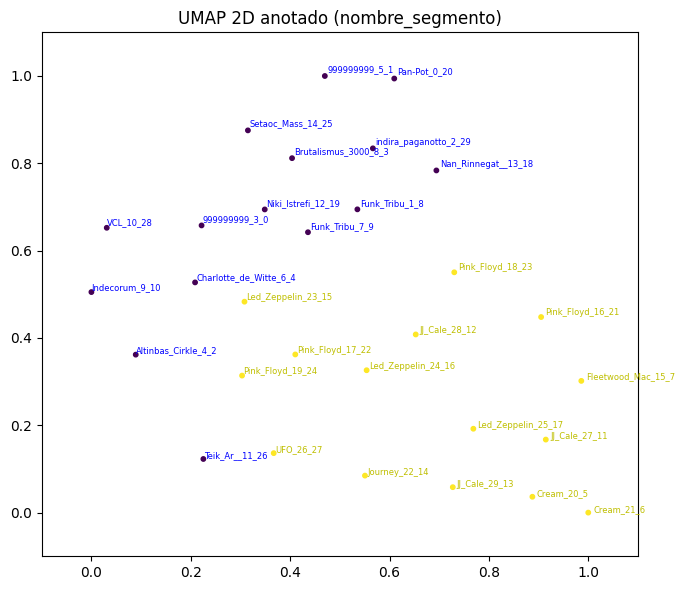

In [ ]:
# -------- 8.6 UMAP 2D con etiquetas de texto --------
color_map = {1: 'b', 2: 'y'}
plt.figure(figsize=(7,6))
plt.scatter(X_2D[:,0], X_2D[:,1], c=label.ravel(), s=10, cmap='viridis')

for i, tex in enumerate(name_c):
    cidx = int(label[i]) if isinstance(label[i], (np.integer, int)) else int(label[i][0])
    c_ = color_map.get(cidx, 'k')
    plt.text(X_2D[i,0]*1.01, X_2D[i,1]*1.01, f"{tex}_{i}", fontsize=6, color=c_)

plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.title('UMAP 2D anotado (nombre_segmento)')
plt.tight_layout()
plt.show()

In [ ]:
# Nombre que quieres inspeccionar (exactamente como aparece en el gráfico)
busca = "Brutalismus_3000_8_4"

# Separar en partes (band, índice, género)
import re

m = re.match(r"(.+)_(\d+)_(\d+)", busca)
if not m:
    raise ValueError("Formato inesperado de nombre, usa algo como 'nombre_índice_tipo'")

band_nom, idx_str, tipo_str = m.groups()
idx = int(idx_str)
tipo = int(tipo_str)

# Mostrar fila correspondiente
fila = X.loc[idx]
print(f"Fila {idx} del Excel original:")
print(f"  Banda: {fila['band']}")
print(f"  Link : {fila['link']}")
print(f"  Género: {fila['type']} (type_num={fila['type_num']})")


Fila 8 del Excel original:
  Banda: Brutalismus 3000
  Link : https://youtu.be/qBPdU57antg?si=8uLZY8Wsob8DVF4d
  Género: Techno (type_num=1)


#9) KNN (k=5, distancia euclídea) + validación cruzada

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5, metric="euclidean")

if len(np.unique(label)) >= 2 and len(label) >= 5:
    scores = cross_val_score(model, Xw_, label.ravel(), cv=5, scoring='accuracy')
    print("Acierto por fold:", scores)
    print("Acierto promedio:", scores.mean())
    print("Desviación estándar:", scores.std())
else:
    print("No hay suficientes clases/muestras para CV 5-fold.")

model.fit(Xw_, label.ravel())
print("Modelo KNN entrenado.")

Acierto por fold: [1.         0.83333333 0.83333333 0.83333333 0.5       ]
Acierto promedio: 0.8
Desviación estándar: 0.1632993161855452
Modelo KNN entrenado.


#10) Guardar modelo y descargar ZIP

In [ ]:
import joblib, shutil
from datetime import datetime
from google.colab import files

os.makedirs("modelo", exist_ok=True)
filename_ = "modelo/techno_vs_psyrock"

model_blob = {
    "Xw_": Xw_,
    "label": label,
    "name_c": name_c,
    "vf": vf,
    "fs": FS_TARGET,
    "modelo": model,
    "type": np.array(["Techno", "Psychedelic Rock"]),  # orden según GENRE_MAP
    "scaler": sca
}
joblib.dump(model_blob, filename_ + ".pkl")

zipname = datetime.now().strftime("%Y_%m_%d_%H_%M_%S") + "_modelo"
shutil.make_archive(zipname, 'zip', 'modelo')
files.download(zipname + ".zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#11) Clasificar una canción nueva por URL (voto por segmentos)